# Import libraries

In [3]:
print('hh')

hh


In [4]:
# kabhi bhi simple lenier regression ML me rare hi use hota hai.
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
salary_df = pd.read_csv(r'C:\Users\LENOVO\OneDrive\Desktop\AIML 27\libraris\dataset\salary_data.csv')
salary_df.head(5)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


# EDA 

In [6]:
salary_df.head(5)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [7]:
salary_df.tail(5)

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [8]:
salary_df.shape

(30, 2)

In [9]:
salary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [10]:
salary_df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [11]:
salary_df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

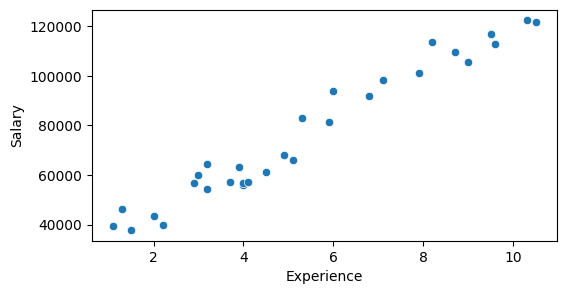

In [12]:
plt.figure(figsize=(6,3))
sns.scatterplot(data = salary_df, 
                x = 'YearsExperience',
                y = 'Salary')

plt.xlabel('Experience')
plt.ylabel('Salary')

plt.show()

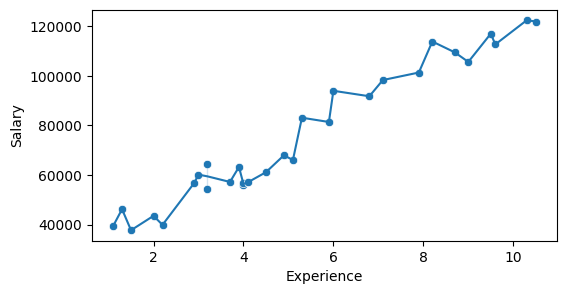

In [13]:
plt.figure(figsize=(6,3))
sns.scatterplot(data = salary_df, 
                x = 'YearsExperience',
                y = 'Salary')
sns.lineplot(data = salary_df, 
                x = 'YearsExperience',
                y = 'Salary')

plt.xlabel('Experience')
plt.ylabel('Salary')

plt.show()

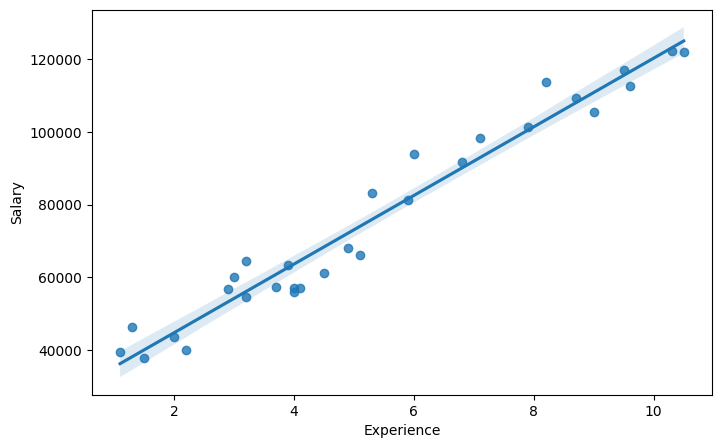

In [14]:
plt.figure(figsize=(8,5))

sns.regplot(data = salary_df, 
                x = 'YearsExperience',
                y = 'Salary')

plt.xlabel('Experience')
plt.ylabel('Salary')

plt.show()

# Feature Selection

In [15]:
# 1st we divide into 2 parts 1st in independent feature 2nd is Dependent feature
X = salary_df[['YearsExperience']]   # esa karne se ye 2D me convert ho gaya . karna jaruri hai indipandent me 2D requried rahta hai. 
Y = salary_df['Salary']

# Split data into train and test

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3)  # test_size=0.3 remaning data traning me chala jayega
                                                                    # test_size=0.2 remaning data traning me chala jayega

In [17]:
print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(21, 1) (9, 1)
(21,) (9,)


# Modal Building
## Linear Regre

In [18]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#

In [19]:
X_test

,YearsExperience
12,4.0
11,4.0
14,4.5
20,6.8
6,3.0
9,3.7
1,1.3
23,8.2
8,3.2


In [20]:
Y_pred = lin_model.predict(X_test)

In [21]:
Y_pred

array([ 63090.31259931,  63090.31259931,  67828.62915809,  89624.88532848,
        53613.67948174,  60247.32266404,  37503.40318189, 102892.17169307,
        55509.00610526])

In [22]:
Y_test

12     56957.0
11     55794.0
14     61111.0
20     91738.0
6      60150.0
9      57189.0
1      46205.0
23    113812.0
8      64445.0
Name: Salary, dtype: float64

# Modal performance evaluation

In [23]:
# Training accuracy
print(lin_model.score(X_train,Y_train))

0.9722686049082931


In [24]:
print(lin_model.score(X_test,Y_test))

0.8717675654548066


In [25]:
from sklearn.metrics import r2_score
print(r2_score(Y_test,Y_pred)*100)
print(f'Modal accuracy {r2_score(Y_test,Y_pred)*100}')


87.17675654548066
Modal accuracy 87.17675654548066
